In [1]:
import pennylane as qml
import numpy as np

In [29]:
n_data = 9
n_anc = 8
n_qubits = n_data + n_anc

dev = qml.device("default.mixed", wires=n_qubits)

In [30]:
data_qubits = list(range(n_data))
anc_z = list(range(n_data, n_data + 4))
anc_x = list(range(n_data + 4, n_qubits))
print("Data qubits:", data_qubits)
print("Z stabilizer qubits:", anc_z)
print("X stabilizer qubits:", anc_x)

Data qubits: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Z stabilizer qubits: [9, 10, 11, 12]
X stabilizer qubits: [13, 14, 15, 16]


In [31]:
# 각 stabilizer가 어떤 data qubit에 연결되는지
Z_stabilizers = [
    [0,1,3,4],
    [1,2,4,5],
    [3,4,6,7],
    [4,5,7,8]
]

X_stabilizers = [
    [0,1,3,4],
    [1,2,4,5],
    [3,4,6,7],
    [4,5,7,8]
]

In [32]:
def measure_Z_stabilizer(anc, qubits):
    for q in qubits:
        qml.CNOT(wires=[q, anc])

In [33]:
def measure_X_stabilizer(anc, qubits):
    qml.Hadamard(wires=anc)
    for q in qubits:
        qml.CNOT(wires=[anc, q])
    qml.Hadamard(wires=anc)

In [34]:
def stabilizer_preparation_block():
    for i, stab in enumerate(Z_stabilizers):
        measure_Z_stabilizer(anc_z[i], stab)
    for i, stab in enumerate(X_stabilizers):
        measure_X_stabilizer(anc_x[i], stab)
    qml.Barrier()

In [35]:
def apply_noise(p):
    for q in range(n_qubits):
        qml.DepolarizingChannel(p, wires=q)

In [36]:
@qml.qnode(dev)
def surface_code_cycle(m=2, p=0.01):

    for i in range(m):
        apply_noise(p)
        stabilizer_preparation_block()
    return qml.state()

(<Figure size 4100x1800 with 1 Axes>, <Axes: >)

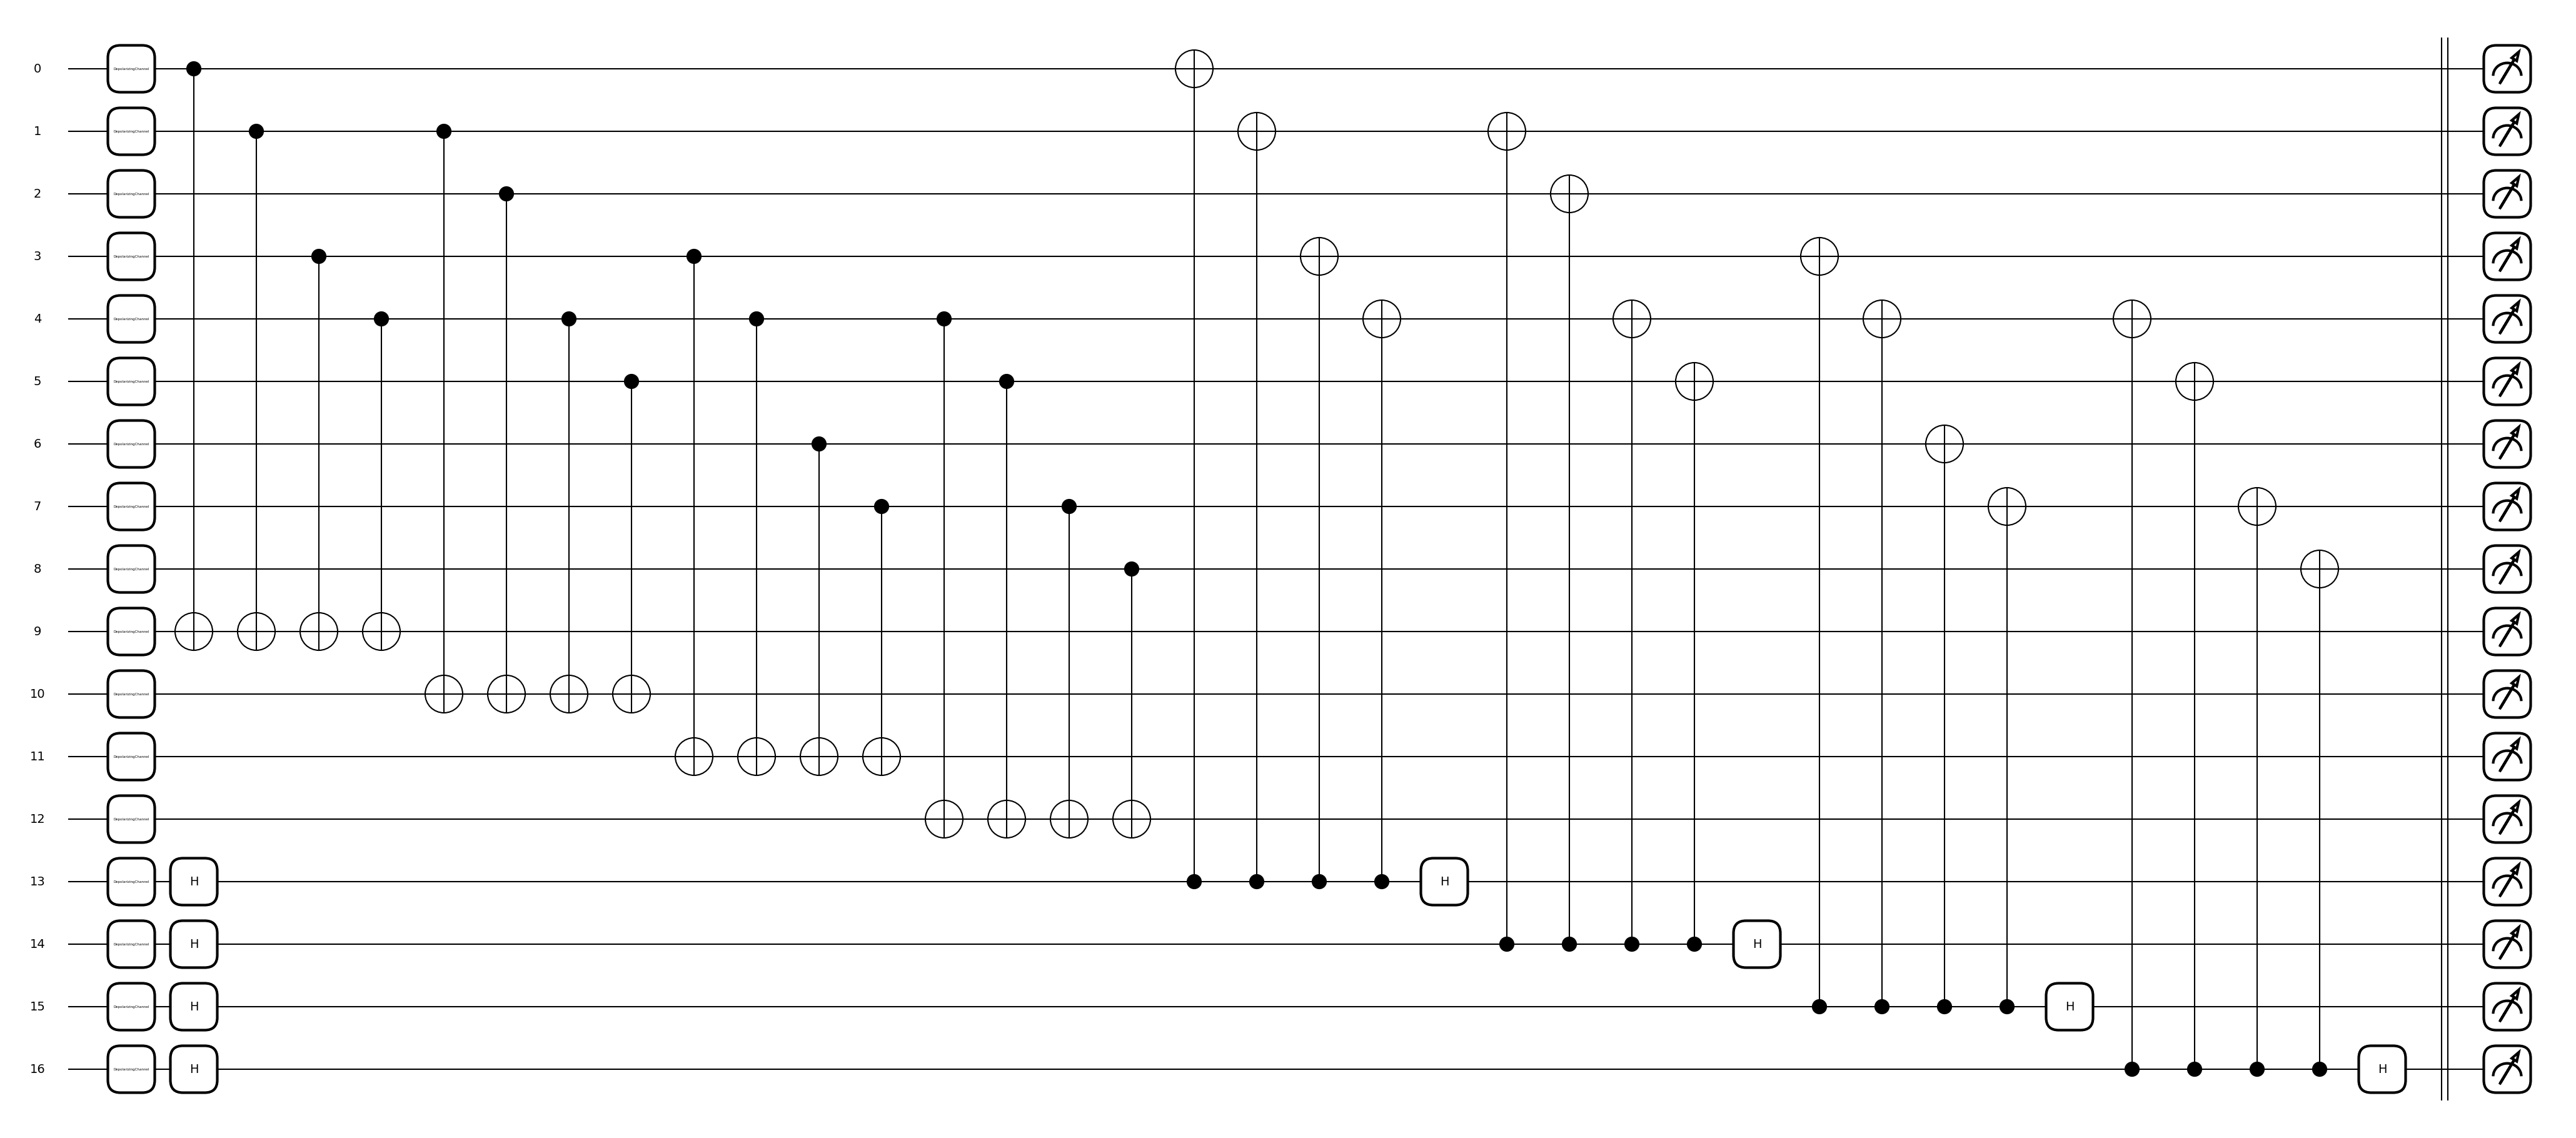

In [37]:
qml.draw_mpl(surface_code_cycle)(m=1, p=0.01)

In [38]:
print(surface_code_cycle(p=0.01))

: 